In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("/heart.csv")

# Preview data
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
print(df.shape)
print(df.info())
print(df.isnull().sum())


(918, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)


SVC()

In [14]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)

In [15]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("SVM Accuracy:", svm_acc)

Logistic Regression Accuracy: 0.8532608695652174
Random Forest Accuracy: 0.875
SVM Accuracy: 0.875


In [18]:
# =========================
# Deep Learning Model (ANN)
# =========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build ANN
ann = Sequential()

ann.add(Dense(16, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dense(8, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

# Compile
ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
ann.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Predict
ann_pred = (ann.predict(X_test) > 0.5).astype("int32")

# Evaluate
from sklearn.metrics import accuracy_score
ann_acc = accuracy_score(y_test, ann_pred)

print("ANN Accuracy:", ann_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.6567 - loss: 0.6280 - val_accuracy: 0.7011 - val_loss: 0.5967
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7125 - loss: 0.5766 - val_accuracy: 0.7717 - val_loss: 0.5534
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7779 - loss: 0.5311 - val_accuracy: 0.8098 - val_loss: 0.5148
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8025 - loss: 0.4888 - val_accuracy: 0.8207 - val_loss: 0.4781
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8215 - loss: 0.4497 - val_accuracy: 0.8315 - val_loss: 0.4462
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8433 - loss: 0.4161 - val_accuracy: 0.8424 - val_loss: 0.4216
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8460 - loss: 0.3913 - val_accuracy: 0.8478 - val_loss: 0.4032
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8488 - loss: 0.3730 - val_accuracy: 0.8478 - val_loss

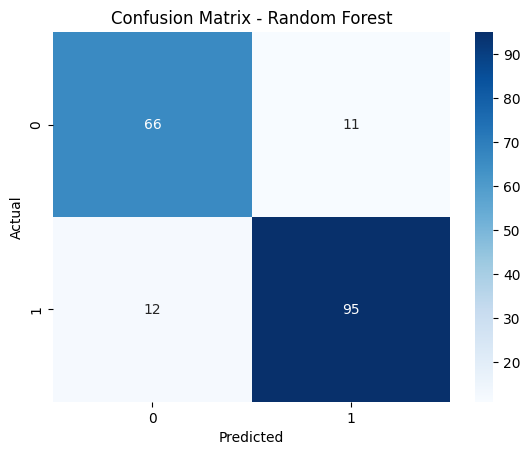

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

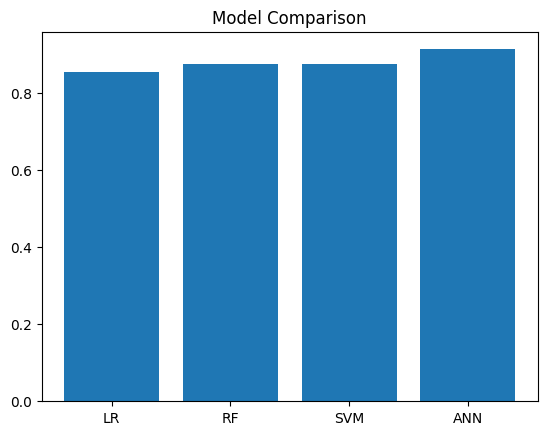

In [19]:
models = ['LR', 'RF', 'SVM', 'ANN']
scores = [lr_acc, rf_acc, svm_acc, ann_acc]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.show()

In [20]:
import pickle

# Save model
pickle.dump(rf, open('model.pkl', 'wb'))

# Save scaler (VERY IMPORTANT)
pickle.dump(scaler, open('scaler.pkl', 'wb'))